In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        continue;

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# Cell 1: Imports & Environment Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

2026-05-05 17:59:37.224854: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778003977.445574      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778003977.504993      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778003978.026476      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778003978.026523      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778003978.026526      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [6]:
# Cell 2: Dataset Path & Class Discovery
# Kaggle Brain Tumor MRI dataset path
DATASET_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

# Walk through directories to find train/test structure
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:
            print(f'{subindent}{f}')

TRAIN_DIR = os.path.join(DATASET_PATH, "Training")
TEST_DIR  = os.path.join(DATASET_PATH, "Testing")

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")

# Count images per class
print("\nTraining set distribution:")
for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"  {cls}: {n} images")

print("\nTest set distribution:")
for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(TEST_DIR, cls)))
    print(f"  {cls}: {n} images")

brain-tumor-mri-dataset/
  Training/
    pituitary/
    notumor/
    meningioma/
    glioma/
  Testing/
    pituitary/
    notumor/
    meningioma/
    glioma/

Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']

Training set distribution:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images

Test set distribution:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images


In [7]:
# Cell 3: Global Hyperparameters
IMG_SIZE    = (224, 224)   # ResNet50 expected input
BATCH_SIZE  = 32
EPOCHS_FE   = 10           # Feature Extraction phase
EPOCHS_FT   = 10           # Fine-Tuning phase
LR_FE       = 1e-3         # Learning rate for feature extraction
LR_FT       = 1e-5         # Lower LR for fine-tuning (avoid catastrophic forgetting)
SEED        = 42

print("Configuration:")
print(f"  Image Size   : {IMG_SIZE}")
print(f"  Batch Size   : {BATCH_SIZE}")
print(f"  Num Classes  : {NUM_CLASSES}")
print(f"  FE Epochs    : {EPOCHS_FE}")
print(f"  FT Epochs    : {EPOCHS_FT}")
print(f"  FE LR        : {LR_FE}")
print(f"  FT LR        : {LR_FT}")

Configuration:
  Image Size   : (224, 224)
  Batch Size   : 32
  Num Classes  : 4
  FE Epochs    : 10
  FT Epochs    : 10
  FE LR        : 0.001
  FT LR        : 1e-05


In [8]:
# Cell 4: Data Augmentation & Generators
# ResNet50 expects inputs preprocessed with its specific function
train_datagen = ImageDataGenerator(
    preprocessing_function=keras.applications.resnet50.preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15        # 15% of training set → validation
)

test_datagen = ImageDataGenerator(
    preprocessing_function=keras.applications.resnet50.preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nTrain batches : {len(train_gen)}")
print(f"Val batches   : {len(val_gen)}")
print(f"Test batches  : {len(test_gen)}")
print(f"\nClass indices : {train_gen.class_indices}")

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Train batches : 149
Val batches   : 27
Test batches  : 50

Class indices : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


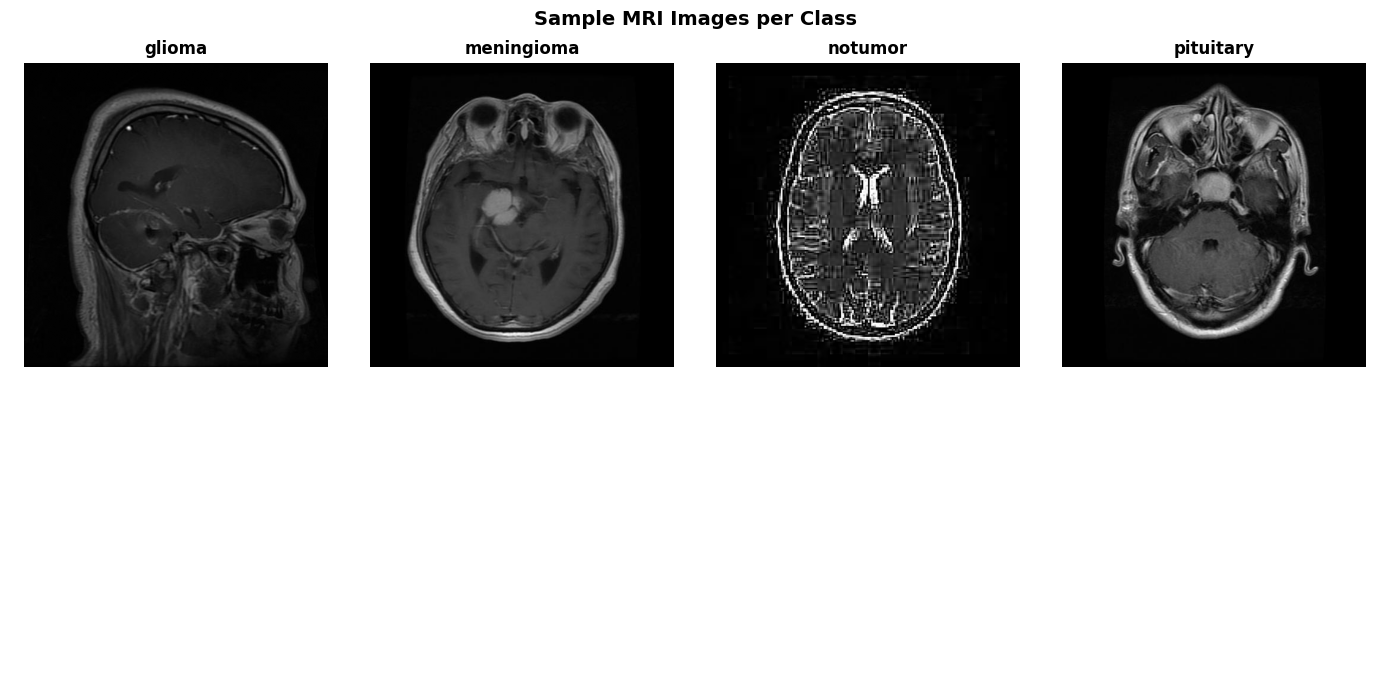

In [9]:
# Cell 5: Visualise Sample Images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_dir)[0]
    img_path = os.path.join(cls_dir, img_file)
    img = plt.imread(img_path)
    axes[i].imshow(img, cmap='gray' if img.ndim == 2 else None)
    axes[i].set_title(cls, fontsize=12, fontweight='bold')
    axes[i].axis('off')

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Sample MRI Images per Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

In [10]:
# Cell 6: Load & Adapt ResNet50
# ── 2.6.1: Load pre-trained ResNet50, exclude top (FC) layers ──
base_model = ResNet50(
    weights='imagenet',
    include_top=False,              # Remove ImageNet 1000-class head
    input_shape=(*IMG_SIZE, 3)
)

print(f"ResNet50 base layers: {len(base_model.layers)}")
print(f"Base model output shape: {base_model.output_shape}")

# ── 2.6.1 / 2.6.2: Freeze entire base for Feature Extraction phase ──
base_model.trainable = False

frozen = sum(1 for l in base_model.layers if not l.trainable)
print(f"Frozen layers: {frozen}")

# ── Add new classification head for NUM_CLASSES ──
inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)          # training=False keeps BN frozen
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)  # Match dataset classes

model = keras.Model(inputs, outputs)
model.summary()

I0000 00:00:1778004087.310963      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778004087.318060      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 base layers: 175
Base model output shape: (None, 7, 7, 2048)
Frozen layers: 175


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,153,860 (92.14 MB)

 Trainable params: 562,052 (2.14 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [11]:
# Cell 7: Feature Extraction Training (frozen base)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fe = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_fe_model.keras', save_best_only=True, verbose=0)
]

print("=" * 50)
print("PHASE 1: Feature Extraction")
print("=" * 50)

start_fe = time.time()

history_fe = model.fit(
    train_gen,
    epochs=EPOCHS_FE,
    validation_data=val_gen,
    callbacks=callbacks_fe,
    verbose=1
)

end_fe = time.time()
fe_training_time = end_fe - start_fe

print(f"\n✅ Feature Extraction Training Time: {fe_training_time:.2f}s "
      f"({fe_training_time/60:.2f} min)")
print(f"   Best Val Accuracy: {max(history_fe.history['val_accuracy']):.4f}")

PHASE 1: Feature Extraction
Epoch 1/10


I0000 00:00:1778004108.679935     168 service.cc:152] XLA service 0x7881e0002750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778004108.679981     168 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778004108.679985     168 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778004110.880100     168 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/149 ━━━━━━━━━━━━━━━━━━━━ 39:46 16s/step - accuracy: 0.3438 - loss: 1.8290

I0000 00:00:1778004116.932188     168 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


149/149 ━━━━━━━━━━━━━━━━━━━━ 113s 655ms/step - accuracy: 0.6992 - loss: 0.9615 - val_accuracy: 0.8679 - val_loss: 0.4101 - learning_rate: 0.0010
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 68s 453ms/step - accuracy: 0.8454 - loss: 0.5242 - val_accuracy: 0.8976 - val_loss: 0.3441 - learning_rate: 0.0010
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 68s 458ms/step - accuracy: 0.8619 - loss: 0.4551 - val_accuracy: 0.9024 - val_loss: 0.3220 - learning_rate: 0.0010
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 70s 469ms/step - accuracy: 0.8867 - loss: 0.3945 - val_accuracy: 0.9095 - val_loss: 0.3200 - learning_rate: 0.0010
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 70s 473ms/step - accuracy: 0.8974 - loss: 0.3386 - val_accuracy: 0.9155 - val_loss: 0.3074 - learning_rate: 0.0010
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 72s 484ms/step - accuracy: 0.9061 - loss: 0.3398 - val_accuracy: 0.9190 - val_loss: 0.2879 - learning_rate: 0.0010
Epoch 7/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 68s 455ms/step - accuracy: 0.9030 - loss

In [12]:
# Cell 8: Fine-Tuning (unfreeze top ResNet layers)
# ── 2.6.2: Unfreeze last 30 layers of ResNet50 ──
base_model.trainable = True

# Selectively unfreeze — keep early layers frozen (low-level features)
UNFREEZE_FROM = len(base_model.layers) - 30
for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= UNFREEZE_FROM)

trainable = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers after unfreezing: {trainable}")

# Recompile with lower LR to avoid catastrophic forgetting
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FT),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_ft_model.keras', save_best_only=True, verbose=0)
]

print("=" * 50)
print("PHASE 2: Fine-Tuning")
print("=" * 50)

start_ft = time.time()

history_ft = model.fit(
    train_gen,
    epochs=EPOCHS_FT,
    validation_data=val_gen,
    callbacks=callbacks_ft,
    verbose=1
)

end_ft = time.time()
ft_training_time = end_ft - start_ft

print(f"\n✅ Fine-Tuning Training Time: {ft_training_time:.2f}s "
      f"({ft_training_time/60:.2f} min)")
print(f"   Total Training Time: {(fe_training_time + ft_training_time)/60:.2f} min")
print(f"   Best Val Accuracy: {max(history_ft.history['val_accuracy']):.4f}")

Trainable layers after unfreezing: 9
PHASE 2: Fine-Tuning
Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 107s 568ms/step - accuracy: 0.9050 - loss: 0.3311 - val_accuracy: 0.9262 - val_loss: 0.2630 - learning_rate: 1.0000e-05
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 69s 459ms/step - accuracy: 0.9300 - loss: 0.2729 - val_accuracy: 0.9310 - val_loss: 0.2469 - learning_rate: 1.0000e-05
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 71s 473ms/step - accuracy: 0.9498 - loss: 0.2338 - val_accuracy: 0.9369 - val_loss: 0.2442 - learning_rate: 1.0000e-05
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 72s 482ms/step - accuracy: 0.9433 - loss: 0.2311 - val_accuracy: 0.9452 - val_loss: 0.2236 - learning_rate: 1.0000e-05
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 70s 465ms/step - accuracy: 0.9519 - loss: 0.2170 - val_accuracy: 0.9464 - val_loss: 0.2342 - learning_rate: 1.0000e-05
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 70s 469ms/step - accuracy: 0.9536 - loss: 0.2016 - val_accuracy: 0.9607 - val_loss: 0.2009 - learning_rate

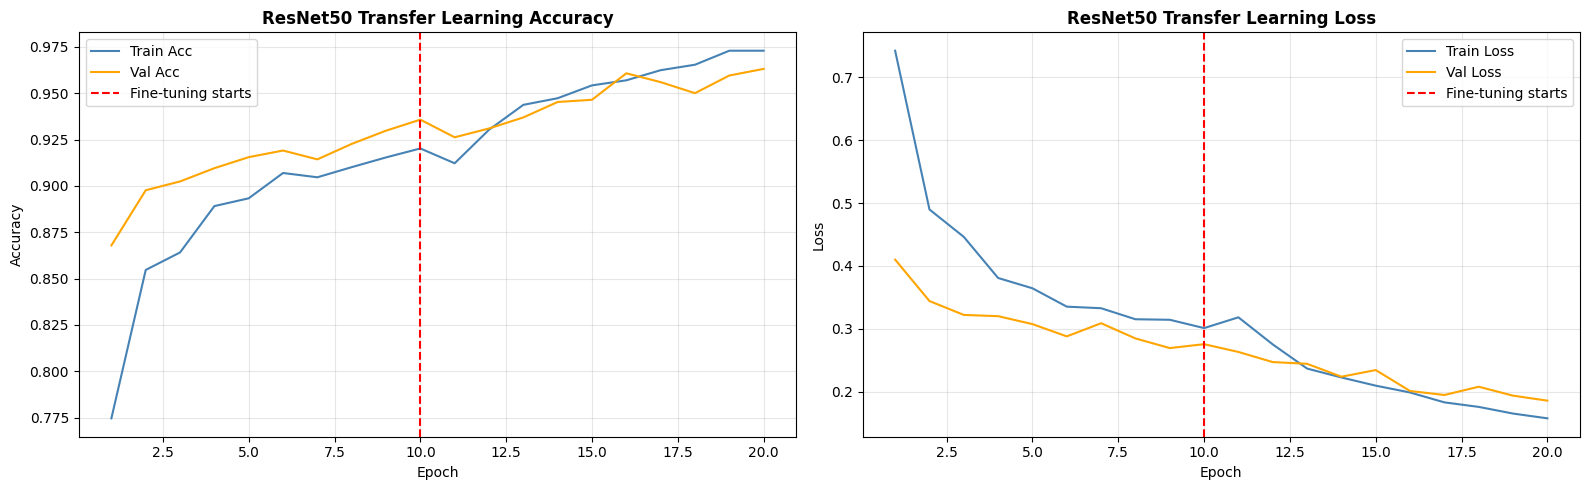

In [13]:
# Cell 9: Training History Plots (both phases)
def plot_history(hist1, hist2, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Combine histories
    acc    = hist1.history['accuracy']    + hist2.history['accuracy']
    val_acc= hist1.history['val_accuracy']+ hist2.history['val_accuracy']
    loss   = hist1.history['loss']        + hist2.history['loss']
    val_loss=hist1.history['val_loss']    + hist2.history['val_loss']
    
    ep1 = len(hist1.history['accuracy'])
    epochs_total = range(1, len(acc) + 1)

    # Accuracy
    axes[0].plot(epochs_total, acc,     label='Train Acc',  color='steelblue')
    axes[0].plot(epochs_total, val_acc, label='Val Acc',    color='orange')
    axes[0].axvline(ep1, color='red', linestyle='--', label='Fine-tuning starts')
    axes[0].set_title(f'{title_prefix} Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(epochs_total, loss,     label='Train Loss', color='steelblue')
    axes[1].plot(epochs_total, val_loss, label='Val Loss',   color='orange')
    axes[1].axvline(ep1, color='red', linestyle='--', label='Fine-tuning starts')
    axes[1].set_title(f'{title_prefix} Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()

plot_history(history_fe, history_ft, title_prefix="ResNet50 Transfer Learning")

In [14]:
# Cell 10: Model Evaluation — Test Set Metrics
print("=" * 50)
print("EVALUATION ON TEST SET")
print("=" * 50)

# Load best model
model = keras.models.load_model('best_ft_model.keras')

# Get predictions
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_prob, axis=1)
y_true       = test_gen.classes

# Core metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec  = recall_score(y_true, y_pred, average='weighted')
f1   = f1_score(y_true, y_pred, average='weighted')

# AUC (multi-class One-vs-Rest)
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
auc_score  = roc_auc_score(y_true_bin, y_pred_prob, multi_class='ovr', average='weighted')

print(f"\n{'Metric':<25} {'Score':>10}")
print("-" * 37)
print(f"{'Accuracy':<25} {acc:>10.4f}")
print(f"{'Precision (weighted)':<25} {prec:>10.4f}")
print(f"{'Recall (weighted)':<25} {rec:>10.4f}")
print(f"{'F1-Score (weighted)':<25} {f1:>10.4f}")
print(f"{'ROC-AUC (weighted OvR)':<25} {auc_score:>10.4f}")
print(f"\n{'Feature Extraction Time':<25} {fe_training_time/60:>9.2f}m")
print(f"{'Fine-Tuning Time':<25} {ft_training_time/60:>9.2f}m")
print(f"{'Total Training Time':<25} {(fe_training_time+ft_training_time)/60:>9.2f}m")

# Full per-class report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

EVALUATION ON TEST SET
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 228ms/step

Metric                         Score
-------------------------------------
Accuracy                      0.9194
Precision (weighted)          0.9229
Recall (weighted)             0.9194
F1-Score (weighted)           0.9174
ROC-AUC (weighted OvR)        0.9862

Feature Extraction Time       12.25m
Fine-Tuning Time              12.31m
Total Training Time           24.55m

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.77      0.86       400
  meningioma       0.86      0.91      0.89       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.94      0.99      0.97       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



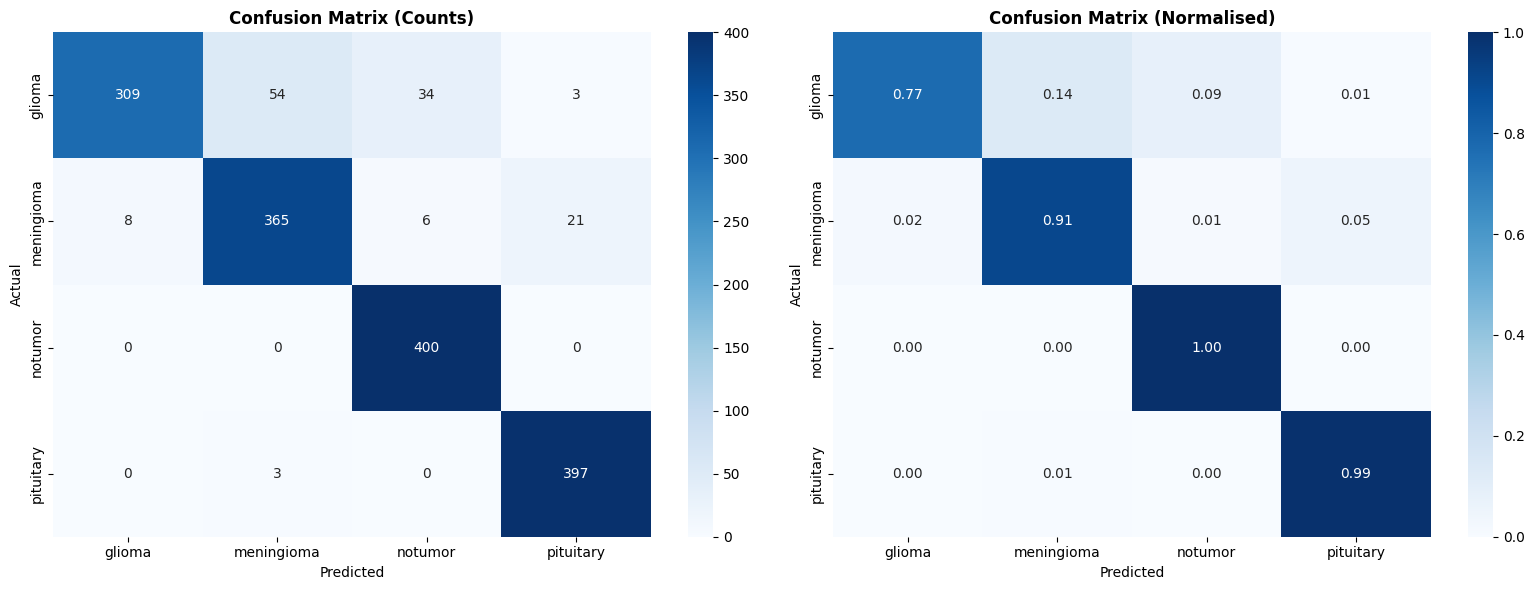

In [15]:
# Cell 11: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Normalised
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

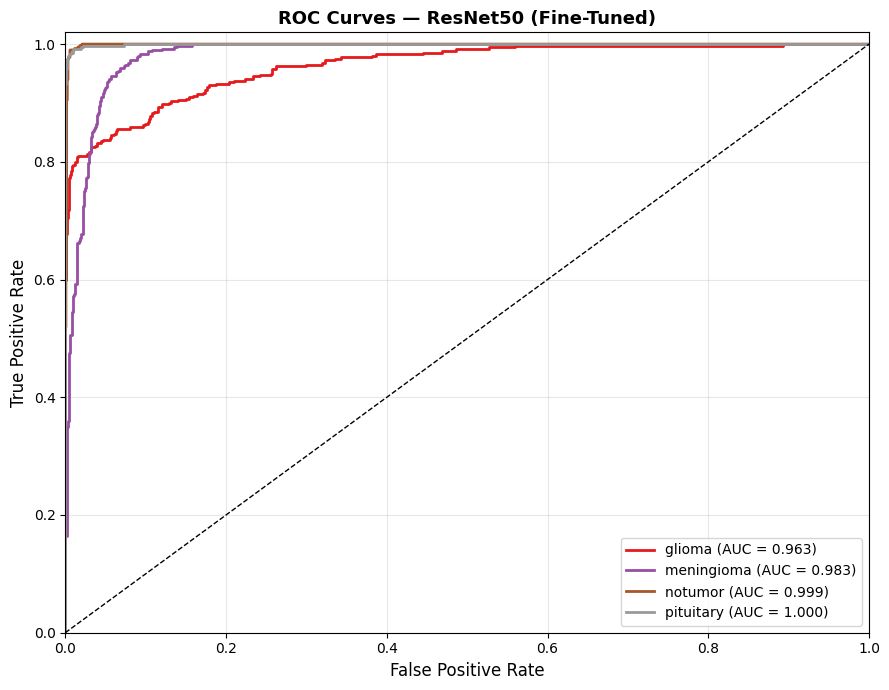

In [16]:
# Cell 12: ROC Curves per Class
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.Set1(np.linspace(0, 1, NUM_CLASSES))

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0,1], [0,1], 'k--', lw=1)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — ResNet50 (Fine-Tuned)', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

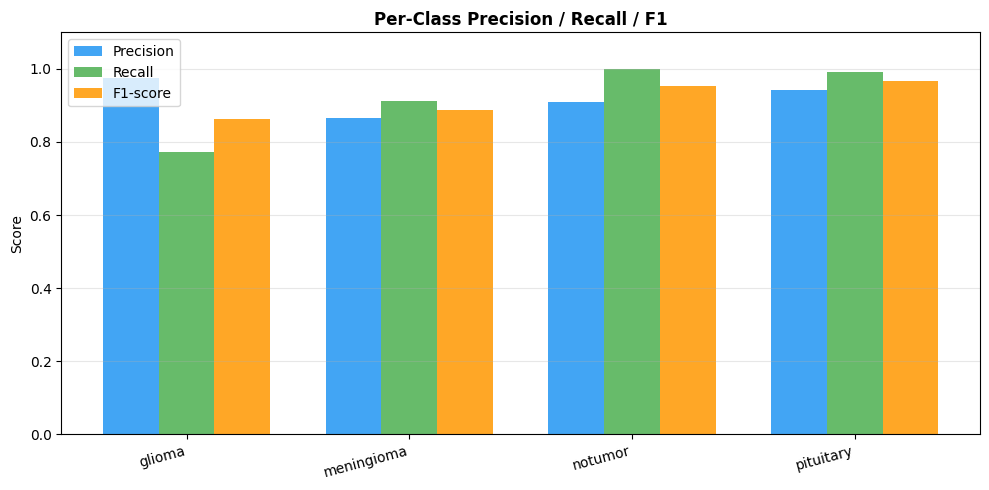

In [17]:
# Cell 13: Per-Class Metrics Visualisation
report = classification_report(
    y_true, y_pred, target_names=CLASS_NAMES, output_dict=True
)
report_df = pd.DataFrame(report).T.iloc[:NUM_CLASSES][['precision','recall','f1-score']]

fig, ax = plt.subplots(figsize=(10, 5))
x   = np.arange(len(CLASS_NAMES))
w   = 0.25
colors_bar = ['#2196F3', '#4CAF50', '#FF9800']

for i, (col, color) in enumerate(zip(report_df.columns, colors_bar)):
    ax.bar(x + i*w, report_df[col], w, label=col.capitalize(), color=color, alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision / Recall / F1', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150)
plt.show()

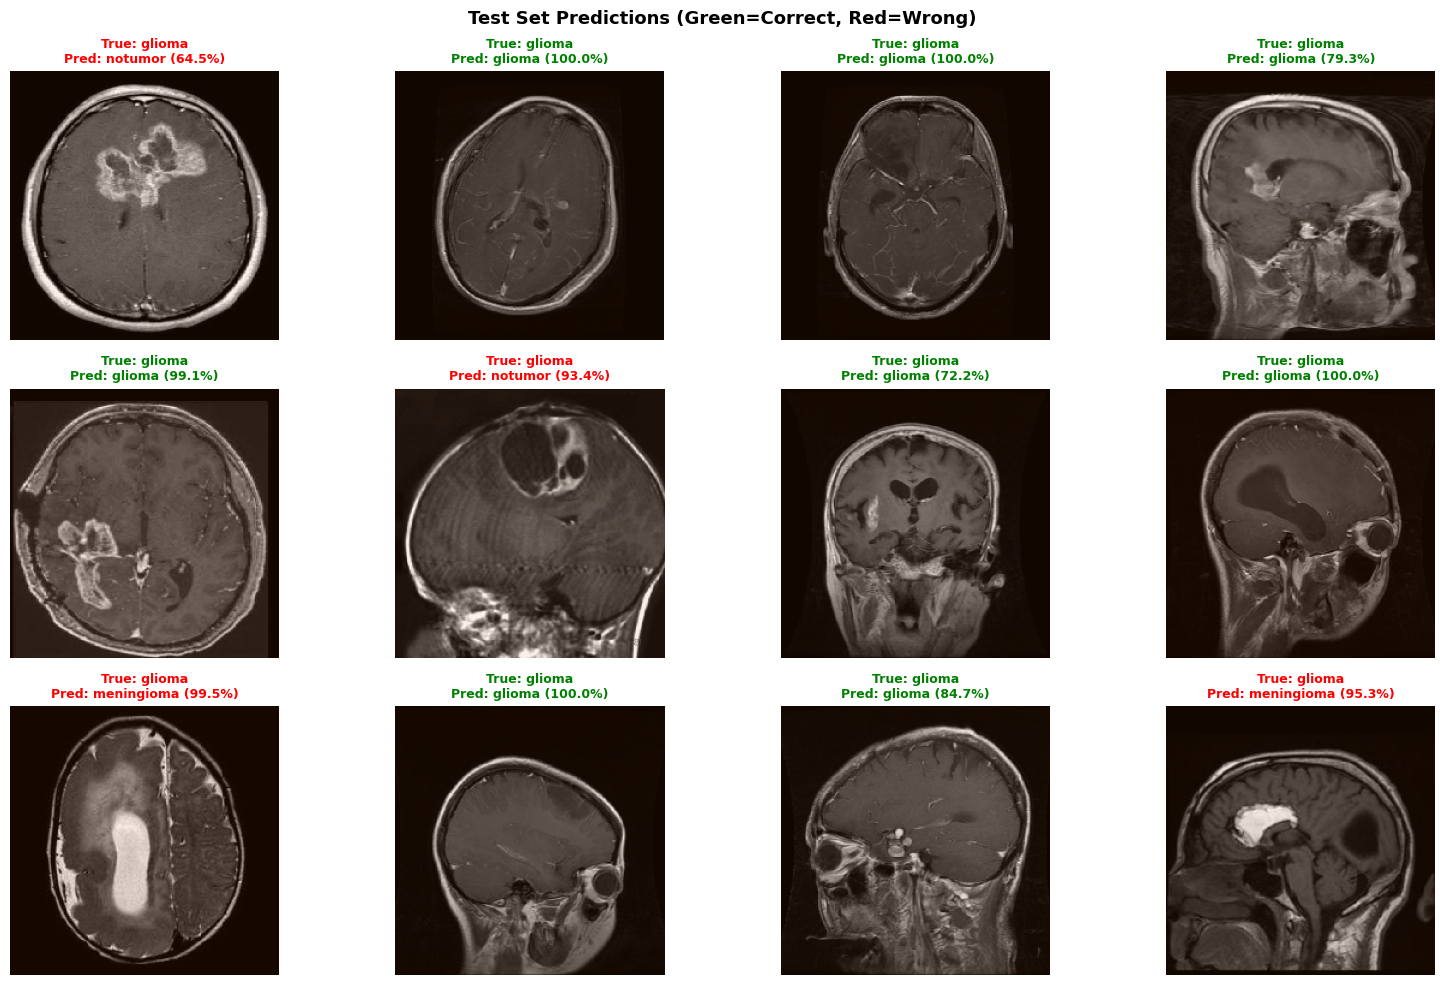

In [18]:
# Cell 14: Visual Predictions on Test Samples
test_gen.reset()
images, labels = next(test_gen)
preds = model.predict(images, verbose=0)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i in range(min(12, len(images))):
    # Reverse ResNet preprocessing for display
    display_img = images[i].copy()
    display_img = (display_img - display_img.min()) / (display_img.max() - display_img.min())
    
    true_label = CLASS_NAMES[np.argmax(labels[i])]
    pred_label = CLASS_NAMES[np.argmax(preds[i])]
    conf       = np.max(preds[i]) * 100
    
    axes[i].imshow(display_img)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label} ({conf:.1f}%)",
        color=color, fontsize=9, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle("Test Set Predictions (Green=Correct, Red=Wrong)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("prediction_samples.png", dpi=150)
plt.show()

In [20]:
# Cell 15: Final Summary Table

print("       TRANSFER LEARNING RESULTS SUMMARY — ResNet50")


summary = {
    "Model"                  : "ResNet50 (ImageNet → Brain Tumor MRI)",
    "Input Size"             : f"{IMG_SIZE[0]}×{IMG_SIZE[1]}",
    "Num Classes"            : NUM_CLASSES,
    "Feature Extraction LR"  : LR_FE,
    "Fine-Tuning LR"         : LR_FT,
    "Test Accuracy"          : f"{acc:.4f}",
    "Weighted Precision"     : f"{prec:.4f}",
    "Weighted Recall"        : f"{rec:.4f}",
    "Weighted F1-Score"      : f"{f1:.4f}",
    "Weighted ROC-AUC"       : f"{auc_score:.4f}",
    "FE Training Time"       : f"{fe_training_time/60:.2f} min",
    "Fine-Tuning Time"       : f"{ft_training_time/60:.2f} min",
    "Total Training Time"    : f"{(fe_training_time+ft_training_time)/60:.2f} min",
}

for k, v in summary.items():
    print(f"  {k:<30} {str(v):>20}")



       TRANSFER LEARNING RESULTS SUMMARY — ResNet50
  Model                          ResNet50 (ImageNet → Brain Tumor MRI)
  Input Size                                  224×224
  Num Classes                                       4
  Feature Extraction LR                         0.001
  Fine-Tuning LR                                1e-05
  Test Accuracy                                0.9194
  Weighted Precision                           0.9229
  Weighted Recall                              0.9194
  Weighted F1-Score                            0.9174
  Weighted ROC-AUC                             0.9862
  FE Training Time                          12.25 min
  Fine-Tuning Time                          12.31 min
  Total Training Time                       24.55 min
